
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

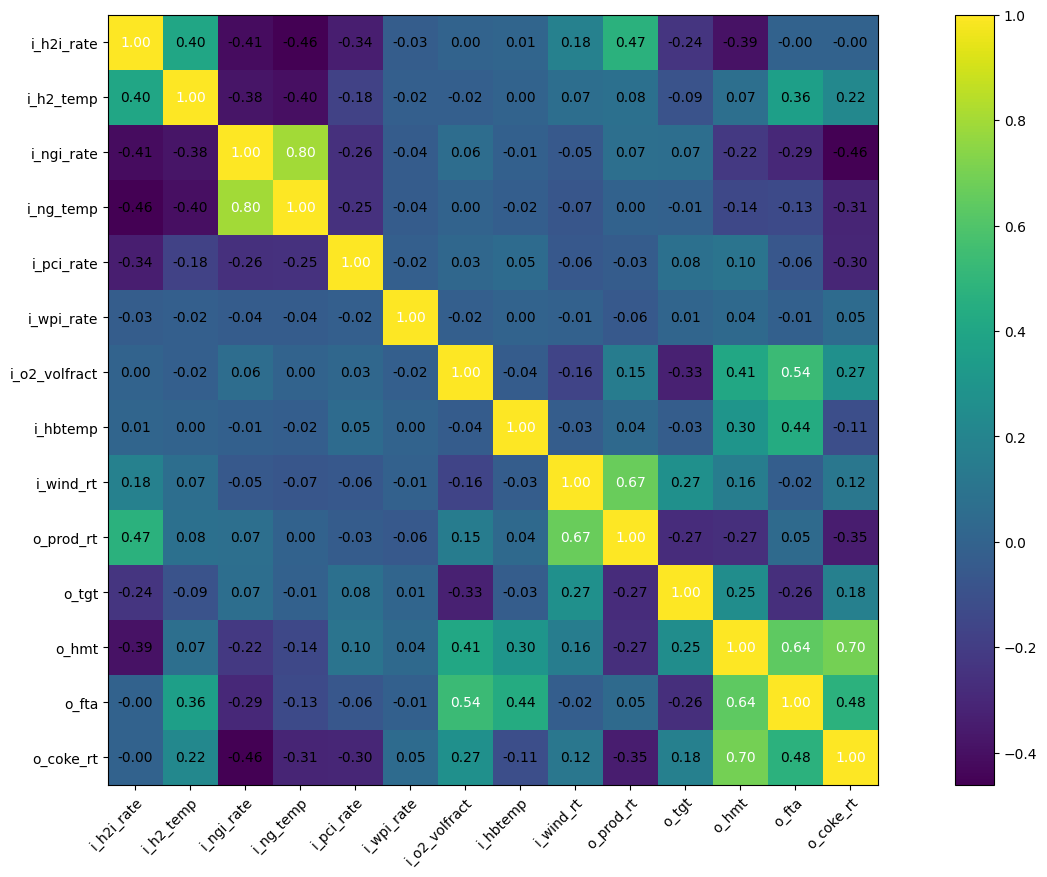

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [17]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.5925486087799072
100 ..... 0.20949405431747437
200 ..... 0.10110381990671158
300 ..... 0.19260740280151367
400 ..... 0.27364876866340637
500 ..... 0.2921205759048462
600 ..... 0.3714486360549927
700 ..... 0.16215145587921143
800 ..... 0.15844318270683289
900 ..... 0.15308570861816406


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.0761, 1300.2124, 8445.5352, 2305.9578,  417.7167]])
y_deviations: tensor([[  50.0264,  523.2630, 1519.8450,  209.9655,   49.8165]])
x_means: tensor([[  12.4406,   17.9707,   41.5764,   25.6129,  412.9782, 1438.1476,
          198.7197]])
x_deviations: tensor([[ 15.2041,  44.5171,  46.6400,   3.3150, 268.0953, 158.4650,  26.6725]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.0497,  776.9494, 6925.6904, 2095.9922,  367.9001]])
tensor([[ 147.1024, 1823.4753, 9965.3799, 2515.9233,  467.5332]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.7635,  -26.5464,   -5.0636,   22.2979,  144.8829, 1279.6826,
          172.0472]])
tensor([[  27.6447,   62.4878,   88.2164,   28.9279,  681.0735, 1596.6125,
          225.3922]])


In [29]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Now add Costs


In [30]:

def regularize_z(z, strength=1e-3):
    
    return strength * torch.sum(z**2)


In [31]:

clamp_min = torch.tensor([[   0,   0,   0,    21,   300,   1200, 150 ]])     ## from Ty
clamp_max = torch.tensor([[ 300, 300, 300,    90,  3000,   1500, 220 ]])



get_x_from_z = lambda z: clamp_min + (clamp_max - clamp_min) * torch.sigmoid(z)


In [32]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  


In [33]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_real = torch.tensor(price_real, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [34]:

lambda_cost = 0.1        ## 0.01    ## 0.001   ## this gave 86% percent of cases improvement
## lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [35]:



for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    ## x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point
    ## x_temp = x_starting_point.clone().detach().requires_grad_(True)
    ## z_init = torch.rand((1,7))*0.4 + 0.3
    
    z_init = torch.rand((1,7))*0.2 + 0.3
    z = torch.nn.Parameter(torch.logit(z_init))    ## this requires grad 
          

    ## x_temp = torch.randn_like(x_starting_point).requires_grad_(True)

    optimizer = torch.optim.Adam([z], lr=learning_rate)
    
   
    
    for j in range(2000):             ## 1000
        
        optimizer.zero_grad()
        
        x_temp = get_x_from_z(  z  )
        
        _, current_y = model_Forward(x_temp)
        
        
        loss_z_reg = regularize_z(z, strength=1e-3)
        loss_main  = torch.mean((current_y - target_y)**2)
        ## loss_cost  = lambda_cost * torch.dot(price_real, x_temp)
        loss_cost  = lambda_cost * (x_temp @ price_real)
        loss       = loss_main + loss_cost + loss_z_reg
        
        loss.backward()
        optimizer.step()
        
        
    
        #######################
        
     
        x_temp_pred_np   = x_temp.detach().numpy()
        ## cost_pred        = np.dot(   price_real, x_temp_pred_np)
        cost_pred        = torch.dot(price_real, x_temp.squeeze()).item()
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
       
        if j % 200 == 0:           ## 20
            print(f"iteration {j} cost: {cost_pred}...H2, PCI, NGI:", x_temp_pred_np[:,:3] )
            print("real cost       :", cost_real)
            print( "total loss", loss      )
            print( "loss_main",  loss_main )
            print( "loss_cost",  loss_cost )
        
   
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append(percent_diff)
        
          
    cost_diffs.append(    cost_diff  )
      

    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np )
    print( "real" )
    print( x_real_np )
    print("...")
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print( wrapped_model(torch.from_numpy(x_real_np))   )
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    print(i)
    print('********************************')




iteration 0 cost: 728.91748046875...H2, PCI, NGI: [[139.82014 111.611   116.05178]]
real cost       : 105.0
total loss tensor([99.9557], grad_fn=<AddBackward0>)
loss_main tensor(27.0621, grad_fn=<MeanBackward0>)
loss_cost tensor([72.8917], grad_fn=<MulBackward0>)
iteration 200 cost: 256.29052734375...H2, PCI, NGI: [[48.916306 37.53954  46.171547]]
real cost       : 105.0
total loss tensor([26.6219], grad_fn=<AddBackward0>)
loss_main tensor(0.9768, grad_fn=<MeanBackward0>)
loss_cost tensor([25.6291], grad_fn=<MulBackward0>)
iteration 400 cost: 123.42743682861328...H2, PCI, NGI: [[22.883238 18.053175 27.682617]]
real cost       : 105.0
total loss tensor([12.6579], grad_fn=<AddBackward0>)
loss_main tensor(0.2840, grad_fn=<MeanBackward0>)
loss_cost tensor([12.3427], grad_fn=<MulBackward0>)
iteration 600 cost: 71.95686340332031...H2, PCI, NGI: [[13.052106 10.63088  18.235123]]
real cost       : 105.0
total loss tensor([7.6031], grad_fn=<AddBackward0>)
loss_main tensor(0.3613, grad_fn=<MeanB

iteration 1800 cost: 14.21718978881836...H2, PCI, NGI: [[2.3618474 2.4031992 4.733202 ]]
real cost       : 140.0
total loss tensor([4.0992], grad_fn=<AddBackward0>)
loss_main tensor(2.5581, grad_fn=<MeanBackward0>)
loss_cost tensor([1.4217], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   1.9752616    1.9916799    4.1722693   21.28907    350.6073
  1208.3644     190.85304  ]]
real
[  30.    0.   40.   21.  300. 1480.  230.]
...
y pred
tensor([[ 126.2275, 1297.8047, 6323.0200, 2169.6887,  469.0006]])
y real
tensor([[  105.5105,   656.4503, 10239.6924,  2036.3041,   371.9643]])
3
********************************
iteration 0 cost: 569.383056640625...H2, PCI, NGI: [[ 96.59455 133.36166  99.28632]]
real cost       : 200.0
total loss tensor([70.3409], grad_fn=<AddBackward0>)
loss_main tensor(13.4007, grad_fn=<MeanBackward0>)
loss_cost tensor([56.9383], grad_fn=<MulBackward0>)
iteration 200 cost: 173.94

iteration 1200 cost: 20.026981353759766...H2, PCI, NGI: [[3.1708474 4.0227194 6.6417465]]
real cost       : 90.0
total loss tensor([2.4866], grad_fn=<AddBackward0>)
loss_main tensor(0.4145, grad_fn=<MeanBackward0>)
loss_cost tensor([2.0027], grad_fn=<MulBackward0>)
iteration 1400 cost: 15.7191162109375...H2, PCI, NGI: [[2.4927819 3.1129947 5.269988 ]]
real cost       : 90.0
total loss tensor([2.1046], grad_fn=<AddBackward0>)
loss_main tensor(0.4554, grad_fn=<MeanBackward0>)
loss_cost tensor([1.5719], grad_fn=<MulBackward0>)
iteration 1600 cost: 12.679710388183594...H2, PCI, NGI: [[2.013786  2.4811227 4.2868867]]
real cost       : 90.0
total loss tensor([1.8444], grad_fn=<AddBackward0>)
loss_main tensor(0.4919, grad_fn=<MeanBackward0>)
loss_cost tensor([1.2680], grad_fn=<MulBackward0>)
iteration 1800 cost: 10.435379981994629...H2, PCI, NGI: [[1.6589516 2.0227304 3.5536866]]
real cost       : 90.0
total loss tensor([1.6574], grad_fn=<AddBackward0>)
loss_main tensor(0.5227, grad_fn=<MeanB

iteration 600 cost: 64.31114959716797...H2, PCI, NGI: [[11.43775  10.771884 15.576531]]
real cost       : 200.0
total loss tensor([7.3456], grad_fn=<AddBackward0>)
loss_main tensor(0.8675, grad_fn=<MeanBackward0>)
loss_cost tensor([6.4311], grad_fn=<MulBackward0>)
iteration 800 cost: 43.856605529785156...H2, PCI, NGI: [[ 7.6910377  7.43015   11.324607 ]]
real cost       : 200.0
total loss tensor([5.5346], grad_fn=<AddBackward0>)
loss_main tensor(1.0892, grad_fn=<MeanBackward0>)
loss_cost tensor([4.3857], grad_fn=<MulBackward0>)
iteration 1000 cost: 32.74296569824219...H2, PCI, NGI: [[5.694675 5.527473 8.873585]]
real cost       : 200.0
total loss tensor([4.6770], grad_fn=<AddBackward0>)
loss_main tensor(1.3318, grad_fn=<MeanBackward0>)
loss_cost tensor([3.2743], grad_fn=<MulBackward0>)
iteration 1200 cost: 24.822046279907227...H2, PCI, NGI: [[4.2952447 4.089906  7.10232  ]]
real cost       : 200.0
total loss tensor([4.0451], grad_fn=<AddBackward0>)
loss_main tensor(1.4819, grad_fn=<Mea

iteration 200 cost: 234.6042938232422...H2, PCI, NGI: [[42.24373  45.043064 41.172638]]
real cost       : 80.0
total loss tensor([24.8023], grad_fn=<AddBackward0>)
loss_main tensor(1.3195, grad_fn=<MeanBackward0>)
loss_cost tensor([23.4604], grad_fn=<MulBackward0>)
iteration 400 cost: 108.76497650146484...H2, PCI, NGI: [[19.342295 20.192787 22.406023]]
real cost       : 80.0
total loss tensor([11.0054], grad_fn=<AddBackward0>)
loss_main tensor(0.0881, grad_fn=<MeanBackward0>)
loss_cost tensor([10.8765], grad_fn=<MulBackward0>)
iteration 600 cost: 63.567535400390625...H2, PCI, NGI: [[11.183608 11.570069 14.526068]]
real cost       : 80.0
total loss tensor([6.4995], grad_fn=<AddBackward0>)
loss_main tensor(0.0882, grad_fn=<MeanBackward0>)
loss_cost tensor([6.3568], grad_fn=<MulBackward0>)
iteration 800 cost: 42.8306884765625...H2, PCI, NGI: [[ 7.4798293  7.770419  10.281906 ]]
real cost       : 80.0
total loss tensor([4.5955], grad_fn=<AddBackward0>)
loss_main tensor(0.2471, grad_fn=<Mea

...

iteration 400 cost: 95.59978485107422...H2, PCI, NGI: [[17.349426 16.491165 19.42183 ]]
real cost       : 40.0
total loss tensor([10.0668], grad_fn=<AddBackward0>)
loss_main tensor(0.4669, grad_fn=<MeanBackward0>)
loss_cost tensor([9.5600], grad_fn=<MulBackward0>)
iteration 600 cost: 55.96611022949219...H2, PCI, NGI: [[10.061061  9.489117 12.465499]]
real cost       : 40.0
total loss tensor([5.9373], grad_fn=<AddBackward0>)
loss_main tensor(0.2899, grad_fn=<MeanBackward0>)
loss_cost tensor([5.5966], grad_fn=<MulBackward0>)
iteration 800 cost: 36.88336944580078...H2, PCI, NGI: [[6.568425 6.22312  8.773091]]
real cost       : 40.0
total loss tensor([3.9441], grad_fn=<AddBackward0>)
loss_main tensor(0.1960, grad_fn=<MeanBackward0>)
loss_cost tensor([3.6883], grad_fn=<MulBackward0>)
iteration 1000 cost: 26.525959014892578...H2, PCI, NGI: [[4.6852345 4.4936495 6.5827413]]
real cost       : 40.0
total loss tensor([2.8967], grad_fn=<AddBackward0>)
loss_main tensor(0.1755, grad_fn=<MeanBackwar

iteration 400 cost: 81.812255859375...H2, PCI, NGI: [[13.726913 15.709618 22.389973]]
real cost       : 80.0
total loss tensor([8.6933], grad_fn=<AddBackward0>)
loss_main tensor(0.4710, grad_fn=<MeanBackward0>)
loss_cost tensor([8.1812], grad_fn=<MulBackward0>)
iteration 600 cost: 47.847599029541016...H2, PCI, NGI: [[ 7.979373  8.957484 13.945246]]
real cost       : 80.0
total loss tensor([5.1654], grad_fn=<AddBackward0>)
loss_main tensor(0.3208, grad_fn=<MeanBackward0>)
loss_cost tensor([4.7848], grad_fn=<MulBackward0>)
iteration 800 cost: 32.274044036865234...H2, PCI, NGI: [[5.3455486 6.002687  9.778321 ]]
real cost       : 80.0
total loss tensor([3.6646], grad_fn=<AddBackward0>)
loss_main tensor(0.3608, grad_fn=<MeanBackward0>)
loss_cost tensor([3.2274], grad_fn=<MulBackward0>)
iteration 1000 cost: 23.510347366333008...H2, PCI, NGI: [[3.888088  4.307162  7.3016677]]
real cost       : 80.0
total loss tensor([2.8823], grad_fn=<AddBackward0>)
loss_main tensor(0.4419, grad_fn=<MeanBackw

iteration 400 cost: 122.67015075683594...H2, PCI, NGI: [[21.574352 19.501205 33.743076]]
real cost       : 200.0
total loss tensor([12.8797], grad_fn=<AddBackward0>)
loss_main tensor(0.5777, grad_fn=<MeanBackward0>)
loss_cost tensor([12.2670], grad_fn=<MulBackward0>)
iteration 600 cost: 72.77691650390625...H2, PCI, NGI: [[12.489055 11.513477 22.614435]]
real cost       : 200.0
total loss tensor([8.1509], grad_fn=<AddBackward0>)
loss_main tensor(0.8287, grad_fn=<MeanBackward0>)
loss_cost tensor([7.2777], grad_fn=<MulBackward0>)
iteration 800 cost: 49.11904525756836...H2, PCI, NGI: [[ 8.283577  7.856489 16.256495]]
real cost       : 200.0
total loss tensor([5.9847], grad_fn=<AddBackward0>)
loss_main tensor(1.0169, grad_fn=<MeanBackward0>)
loss_cost tensor([4.9119], grad_fn=<MulBackward0>)
iteration 1000 cost: 38.28579330444336...H2, PCI, NGI: [[ 6.406771   6.1125946 13.092229 ]]
real cost       : 200.0
total loss tensor([5.2712], grad_fn=<AddBackward0>)
loss_main tensor(1.3782, grad_fn=<

iteration 400 cost: 119.93939208984375...H2, PCI, NGI: [[23.23372  14.234956 25.539108]]
real cost       : 60.0
total loss tensor([12.6234], grad_fn=<AddBackward0>)
loss_main tensor(0.5907, grad_fn=<MeanBackward0>)
loss_cost tensor([11.9939], grad_fn=<MulBackward0>)
iteration 600 cost: 71.28412628173828...H2, PCI, NGI: [[13.3986635  8.69559   17.987766 ]]
real cost       : 60.0
total loss tensor([8.2294], grad_fn=<AddBackward0>)
loss_main tensor(1.0508, grad_fn=<MeanBackward0>)
loss_cost tensor([7.1284], grad_fn=<MulBackward0>)
iteration 800 cost: 48.686580657958984...H2, PCI, NGI: [[ 8.94115    6.1247687 13.594429 ]]
real cost       : 60.0
total loss tensor([6.3211], grad_fn=<AddBackward0>)
loss_main tensor(1.3913, grad_fn=<MeanBackward0>)
loss_cost tensor([4.8687], grad_fn=<MulBackward0>)
iteration 1000 cost: 39.425628662109375...H2, PCI, NGI: [[ 7.152486  5.158229 11.314915]]
real cost       : 60.0
total loss tensor([5.8020], grad_fn=<AddBackward0>)
loss_main tensor(1.7899, grad_fn=

iteration 400 cost: 111.50603485107422...H2, PCI, NGI: [[20.458178 18.73063  21.885391]]
real cost       : 120.0
total loss tensor([11.6528], grad_fn=<AddBackward0>)
loss_main tensor(0.4594, grad_fn=<MeanBackward0>)
loss_cost tensor([11.1506], grad_fn=<MulBackward0>)
iteration 600 cost: 65.6577377319336...H2, PCI, NGI: [[11.858685 10.857603 14.730795]]
real cost       : 120.0
total loss tensor([7.1656], grad_fn=<AddBackward0>)
loss_main tensor(0.5346, grad_fn=<MeanBackward0>)
loss_cost tensor([6.5658], grad_fn=<MulBackward0>)
iteration 800 cost: 44.87124252319336...H2, PCI, NGI: [[ 8.005197  7.373067 10.954779]]
real cost       : 120.0
total loss tensor([5.3518], grad_fn=<AddBackward0>)
loss_main tensor(0.7802, grad_fn=<MeanBackward0>)
loss_cost tensor([4.4871], grad_fn=<MulBackward0>)
iteration 1000 cost: 34.68975067138672...H2, PCI, NGI: [[6.1639075 5.569163  8.929918 ]]
real cost       : 120.0
total loss tensor([4.6823], grad_fn=<AddBackward0>)
loss_main tensor(1.1159, grad_fn=<Mean

In [36]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


Average Euclidean Distance of Xs:
Method A: 429.16614


In [37]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


Average Euclidean Distance of Ys:
Method A: 1957.519


In [38]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -82.06238208948312
average percent diff: 26.633123127663083 %


In [39]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 99.4994994994995 % of cases


In [40]:

print(total)
print(better)


999
994
